
Carregando arquivo...

Valores únicos de ANO:
[2022 2023 2024]

Colunas de avaliação detectadas:
INSTITUIÇÃO DE ENSINO
REC AV1
REC AV2
REC AV3
REC AV4
REC PSICOLOGIA

Contagem de valores por coluna:
INSTITUIÇÃO DE ENSINO -> 3029
REC AV1 -> 860
REC AV2 -> 860
REC AV3 -> 860
REC AV4 -> 296
REC PSICOLOGIA -> 860

IPP por ano:
ANO
2022    858
2023     60
2024     41
Name: IPP, dtype: int64

Contagem de valores válidos para IAN:
ANO
2022     860
2023    1014
2024    1156
Name: IAN, dtype: int64


/tmp/ipykernel_263/2661136448.py:98: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  dataset["IDA"] = dataset[[col_mat, col_port, col_ing]].applymap(limpar_numero).mean(axis=1)


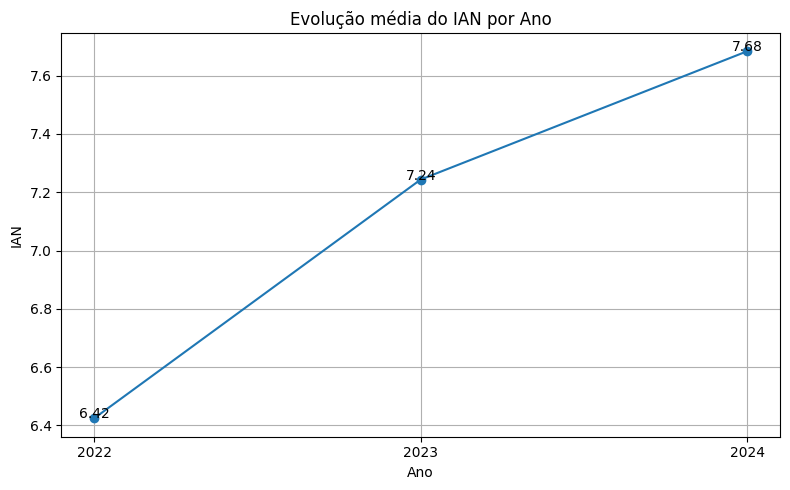


Contagem de valores válidos para IDA:
ANO
2022     860
2023    1014
2024    1156
Name: IDA, dtype: int64


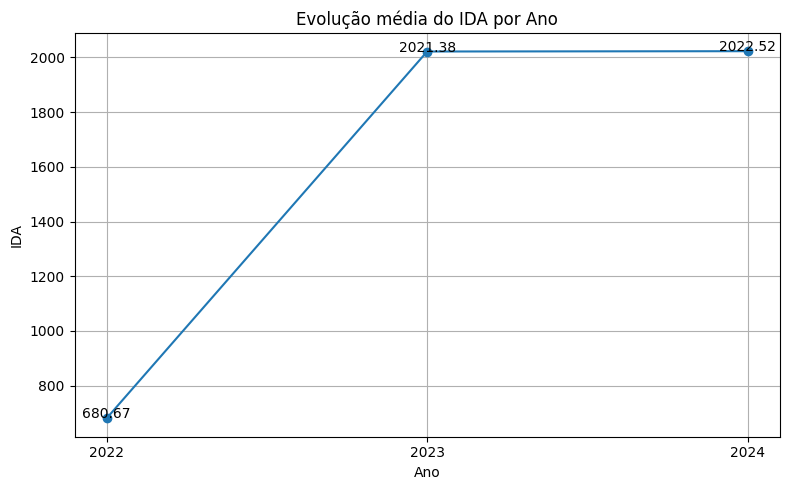


Contagem de valores válidos para IEG:
ANO
2022     860
2023     938
2024    1156
Name: IEG, dtype: int64


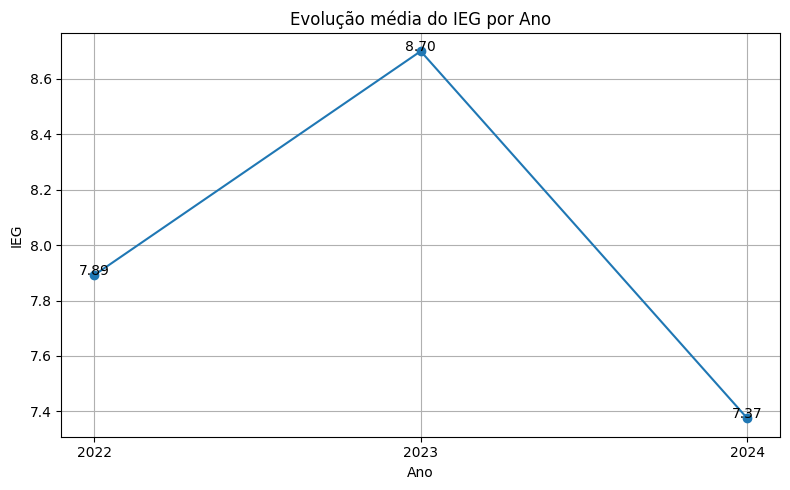


Contagem de valores válidos para IAA:
ANO
2022     860
2023     951
2024    1054
Name: IAA, dtype: int64


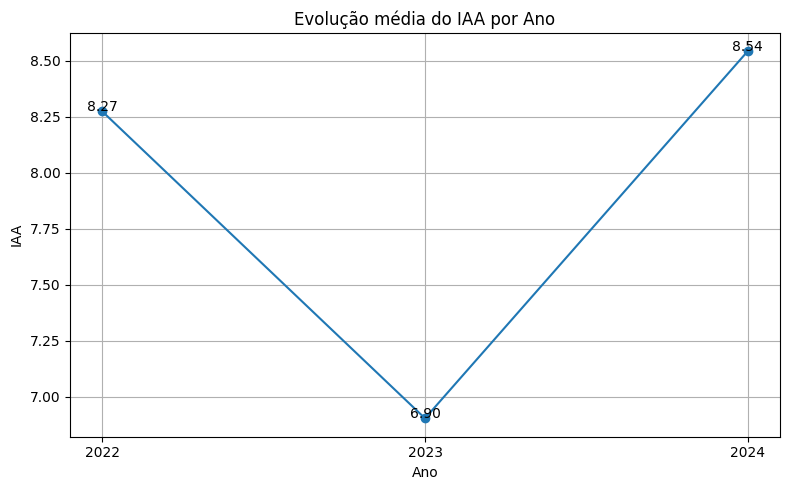


Contagem de valores válidos para IPS:
ANO
2022     860
2023     945
2024    1054
Name: IPS, dtype: int64


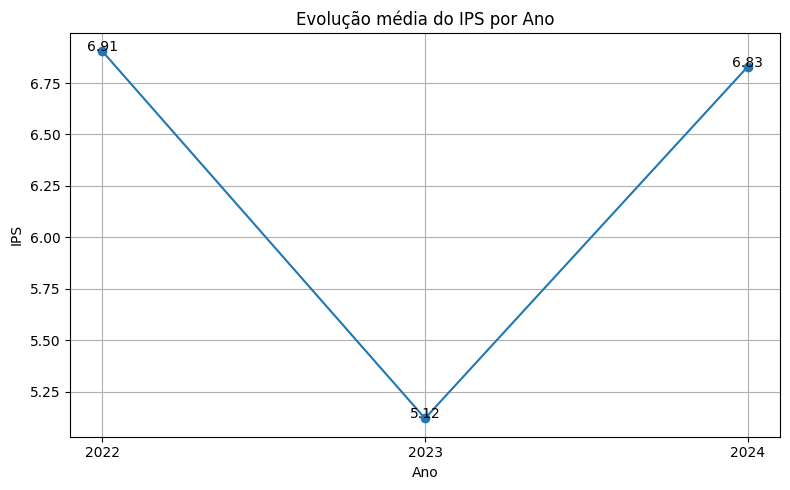


Contagem de valores válidos para IPP:
ANO
2022    858
2023     60
2024     41
Name: IPP, dtype: int64


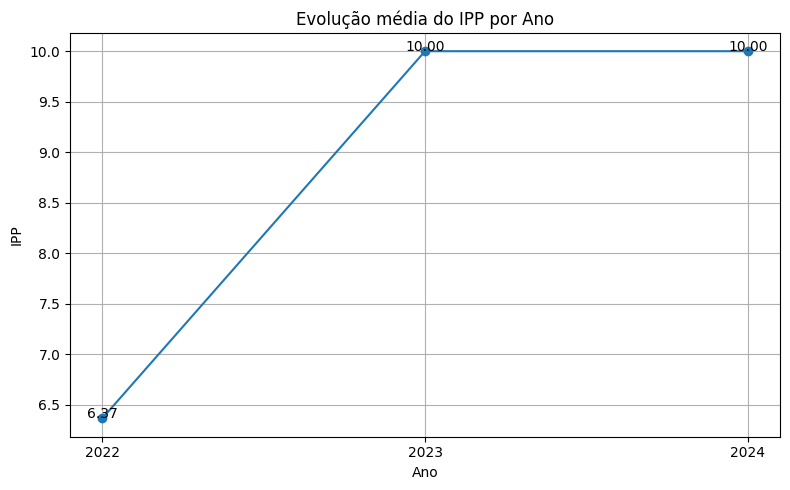


Contagem de valores válidos para IPV:
ANO
2022     860
2023     938
2024    1054
Name: IPV, dtype: int64


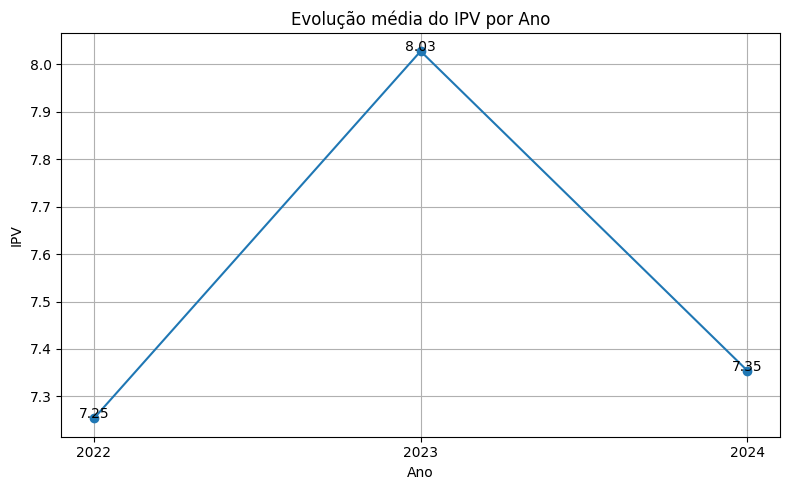


Contagem de valores válidos para INDE:
ANO
2022    860
2023    600
2024    472
Name: INDE, dtype: int64


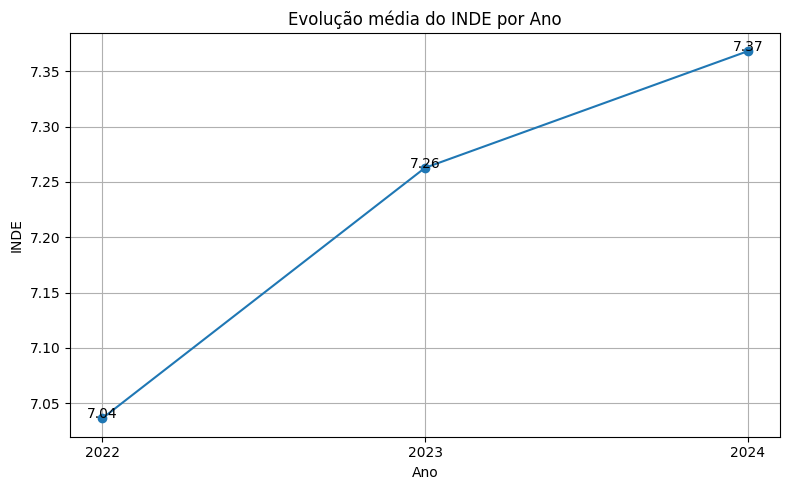


Correlação:
           IAN       IDA       IEG       IAA       IPS       IPP       IPV  \
IAN   1.000000  0.184720 -0.060345  0.034162  0.004548  0.281785  0.148880   
IDA   0.184720  1.000000  0.015195 -0.090231 -0.225072  0.668221  0.175650   
IEG  -0.060345  0.015195  1.000000  0.133078 -0.046264 -0.140851  0.558200   
IAA   0.034162 -0.090231  0.133078  1.000000  0.157373 -0.000946  0.062728   
IPS   0.004548 -0.225072 -0.046264  0.157373  1.000000  0.149304 -0.048750   
IPP   0.281785  0.668221 -0.140851 -0.000946  0.149304  1.000000  0.449247   
IPV   0.148880  0.175650  0.558200  0.062728 -0.048750  0.449247  1.000000   
INDE  0.403413  0.137355  0.545400  0.244117  0.063088  0.368976  0.620750   

          INDE  
IAN   0.403413  
IDA   0.137355  
IEG   0.545400  
IAA   0.244117  
IPS   0.063088  
IPP   0.368976  
IPV   0.620750  
INDE  1.000000  


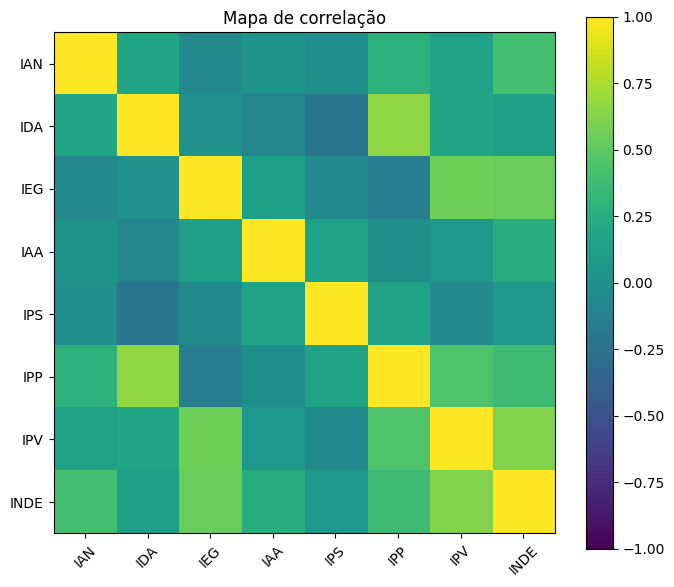


ANÁLISE FINALIZADA


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.ion()

arquivo = "pede.xlsx"

indicadores = [
    "IAN","IDA","IEG","IAA","IPS","IPP","IPV","INDE"
]

def limpar_numero(x):
    if pd.isna(x):
        return np.nan
    x = str(x).strip().replace(",", ".")
    try:
        return float(x)
    except:
        return np.nan

def encontrar_coluna(dataset, palavras):
    for palavra in palavras:
        for col in dataset.columns:
            if palavra in col:
                return col
    return None



print("\nCarregando arquivo...")
sheets = pd.read_excel(arquivo, sheet_name=None)
dfs = []

for nome, df in sheets.items():
    nome_limpo = nome.strip().upper()

    if "2022" in nome_limpo:
        df["ANO"] = 2022
    elif "2023" in nome_limpo:
        df["ANO"] = 2023
    elif "2024" in nome_limpo:
        df["ANO"] = 2024
    else:
        df["ANO"] = np.nan

    dfs.append(df)

dataset = pd.concat(dfs, ignore_index=True)
dataset.columns = dataset.columns.str.strip().str.upper()
dataset = dataset.loc[:, ~dataset.columns.duplicated()]

print("\nValores únicos de ANO:")
print(dataset["ANO"].unique())


dataset.replace(["", " ", "NA", "NAN"], np.nan, inplace=True)
dataset.drop_duplicates(inplace=True)


col_mat = encontrar_coluna(dataset, ["MAT"])
col_port = encontrar_coluna(dataset, ["PORT"])
col_ing = encontrar_coluna(dataset, ["ING"])

col_ieg = encontrar_coluna(dataset, ["IEG"])
col_iaa = encontrar_coluna(dataset, ["IAA"])
col_ips = encontrar_coluna(dataset, ["IPS"])
col_ipv = encontrar_coluna(dataset, ["IPV"])
col_inde = encontrar_coluna(dataset, ["INDE"])

col_defas = encontrar_coluna(dataset, ["DEFAS"])


def calcular_ian(defas):
    if pd.isna(defas):
        return np.nan
    if defas >= 0:
        return 10
    elif defas == -1:
        return 7.5
    elif defas == -2:
        return 5
    else:
        return 2.5

if col_defas:
    dataset[col_defas] = dataset[col_defas].apply(limpar_numero)

    dataset["IAN_CALCULADO"] = dataset[col_defas].apply(calcular_ian)

    if "IAN" in dataset.columns:
        dataset["IAN"] = dataset["IAN"].combine_first(dataset["IAN_CALCULADO"])
    else:
        dataset["IAN"] = dataset["IAN_CALCULADO"]


if col_mat and col_port and col_ing:
    dataset["IDA"] = dataset[[col_mat, col_port, col_ing]].applymap(limpar_numero).mean(axis=1)


if col_ieg:
    dataset["IEG"] = dataset[col_ieg].apply(limpar_numero)
if col_iaa:
    dataset["IAA"] = dataset[col_iaa].apply(limpar_numero)
if col_ips:
    dataset["IPS"] = dataset[col_ips].apply(limpar_numero)
if col_ipv:
    dataset["IPV"] = dataset[col_ipv].apply(limpar_numero)
if col_inde:
    dataset["INDE"] = dataset[col_inde].apply(limpar_numero)



def converter_avaliacao(x):
    if pd.isna(x):
        return np.nan

    x = str(x).strip().upper()

    if "BOLSA" in x:
        return 10
    elif "PROMOVIDO" in x:
        return 8
    elif "MANTIDO" in x:
        return 5
    elif "REQUER" in x:
        return 2
    else:
        return np.nan

cols_av = []

for col in dataset.columns:
    if dataset[col].dtype == object:
        amostra = dataset[col].dropna().astype(str).str.upper()

        if any(amostra.str.contains("PROMOVIDO|MANTIDO|BOLSA|REQUER", na=False)):
            cols_av.append(col)

print("\nColunas de avaliação detectadas:")
for c in cols_av:
    print(c)

print("\nContagem de valores por coluna:")
for col in cols_av:
    print(col, "->", dataset[col].notna().sum())


cols_num = []

for col in cols_av:
    nova_col = col + "_NUM"
    dataset[nova_col] = dataset[col].apply(converter_avaliacao)
    cols_num.append(nova_col)


dataset["IPP"] = dataset[cols_num].mean(axis=1, skipna=True)

print("\nIPP por ano:")
print(dataset.groupby("ANO")["IPP"].count())



for col in indicadores:
    if col in dataset.columns:

        print(f"\nContagem de valores válidos para {col}:")
        print(dataset.groupby("ANO")[col].count())

        temp = dataset[["ANO", col]].dropna()

        if len(temp) == 0:
            continue

        medias = temp.groupby("ANO")[col].mean().sort_index()
        medias.index = medias.index.astype(int)

        plt.figure(figsize=(8,5))
        plt.plot(medias.index, medias.values, marker="o")

        plt.xticks(medias.index)

        for x, y in zip(medias.index, medias.values):
            plt.text(x, y, f"{y:.2f}", ha='center')

        plt.title(f"Evolução média do {col} por Ano")
        plt.xlabel("Ano")
        plt.ylabel(col)
        plt.grid()
        plt.tight_layout()
        plt.show()


cols_corr = [c for c in indicadores if c in dataset.columns]
corr = dataset[cols_corr].corr()

print("\nCorrelação:")
print(corr)

plt.figure(figsize=(7,6))
plt.imshow(corr, vmin=-1, vmax=1)
plt.colorbar()
plt.xticks(range(len(cols_corr)), cols_corr, rotation=45)
plt.yticks(range(len(cols_corr)), cols_corr)
plt.title("Mapa de correlação")
plt.tight_layout()
plt.show()

print("\nANÁLISE FINALIZADA")


COLUNAS DO DATASET:
Index(['RA', 'FASE', 'TURMA', 'NOME', 'ANO NASC', 'IDADE 22', 'GÊNERO',
       'ANO INGRESSO', 'INSTITUIÇÃO DE ENSINO', 'PEDRA 20', 'PEDRA 21',
       'PEDRA 22', 'INDE 22', 'CG', 'CF', 'CT', 'Nº AV', 'AVALIADOR1',
       'REC AV1', 'AVALIADOR2', 'REC AV2', 'AVALIADOR3', 'REC AV3',
       'AVALIADOR4', 'REC AV4', 'IAA', 'IEG', 'IPS', 'REC PSICOLOGIA', 'IDA',
       'MATEM', 'PORTUG', 'INGLÊS', 'INDICADO', 'ATINGIU PV', 'IPV', 'IAN',
       'FASE IDEAL', 'DEFAS', 'DESTAQUE IEG', 'DESTAQUE IDA', 'DESTAQUE IPV',
       'ANO', 'INDE 2023', 'PEDRA 2023', 'NOME ANONIMIZADO', 'DATA DE NASC',
       'IDADE', 'PEDRA 23', 'INDE 23', 'IPP', 'MAT', 'POR', 'ING',
       'FASE IDEAL', 'DEFASAGEM', 'DESTAQUE IPV.1', 'INDE 2024', 'PEDRA 2024',
       'AVALIADOR5', 'AVALIADOR6', 'ESCOLA', 'ATIVO/ INATIVO',
       'ATIVO/ INATIVO.1'],
      dtype='object')

Coluna de defasagem: DEFASAGEM

Distribuição do risco:
RISCO_DEFASAGEM
0    1944
1    1086
Name: count, dtype: int64

Indicador

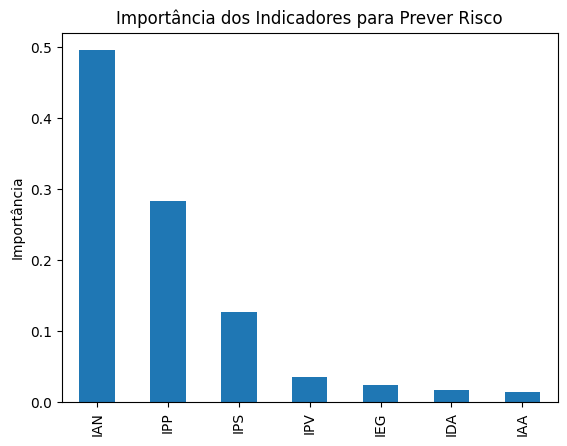


Exemplo de probabilidades:
   PROB_RISCO_DEFASAGEM   IAN  IDA  IEG  IAA  IPS  IPP    IPV
0                 0.035   5.0  4.0  4.1  8.3  5.6  NaN  7.278
1                 0.000  10.0  6.8  5.2  8.8  6.3  NaN  6.778
2                 0.000  10.0  5.6  7.9  0.0  5.6  NaN  7.556
3                 0.005  10.0  5.0  4.5  8.8  5.6  NaN  5.278
4                 0.000  10.0  5.2  8.6  7.9  5.6  NaN  7.389


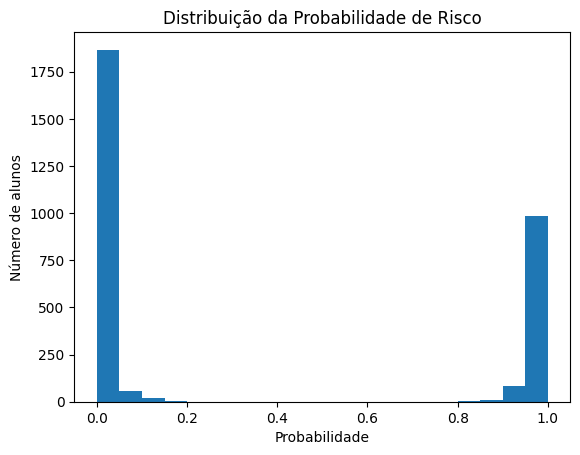


Pipeline salvo como modelo_risco_defasagem.pkl

Pipeline carregado com sucesso!

Probabilidade prevista para primeiros alunos:
[0.035 0.    0.    0.005 0.   ]


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier

import joblib

plt.ion()


arquivo = "pede.xlsx"

sheets = pd.read_excel(arquivo, sheet_name=None)

dfs = []

for nome_aba, df in sheets.items():

    ano = ''.join(filter(str.isdigit, nome_aba))

    if ano != "":
        df["ANO"] = int(ano)

    dfs.append(df)

dataset = pd.concat(dfs, ignore_index=True)


dataset.columns = dataset.columns.str.strip().str.upper()

dataset.replace(["", " ", "NA", "NAN"], np.nan, inplace=True)

dataset.drop_duplicates(inplace=True)

print("\nCOLUNAS DO DATASET:")
print(dataset.columns)


indicadores = ["IAN","IDA","IEG","IAA","IPS","IPP","IPV","INDE"]

for col in indicadores:

    if col in dataset.columns:

        dataset[col] = pd.to_numeric(dataset[col], errors="coerce")


defasagem_col = None

for col in dataset.columns:

    if "DEFASAGEM" in col:

        defasagem_col = col
        break

if defasagem_col is None:

    raise ValueError("Nenhuma coluna DEFASAGEM encontrada.")

print("\nColuna de defasagem:", defasagem_col)


dataset["RISCO_DEFASAGEM"] = dataset[defasagem_col].apply(
    lambda x: 1 if pd.notna(x) and x < 0 else 0
)

print("\nDistribuição do risco:")

print(dataset["RISCO_DEFASAGEM"].value_counts())


indicadores_ml = ["IAN","IDA","IEG","IAA","IPS","IPP","IPV"]

features = [c for c in indicadores_ml if c in dataset.columns]

print("\nIndicadores utilizados:")

print(features)

X = dataset[features]

y = dataset["RISCO_DEFASAGEM"]


X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,
    test_size=0.30,
    random_state=42
)


pipeline = Pipeline([

    ("imputer", SimpleImputer(strategy="mean")),

    ("model", RandomForestClassifier(

        n_estimators=200,
        random_state=42
    ))
])


pipeline.fit(X_train, y_train)


y_pred = pipeline.predict(X_test)

print("\n===== MATRIZ DE CONFUSÃO =====")

print(confusion_matrix(y_test, y_pred))

print("\n===== RELATÓRIO DE CLASSIFICAÇÃO =====")

print(classification_report(y_test, y_pred))


modelo = pipeline.named_steps["model"]

importancia = pd.Series(

    modelo.feature_importances_,
    index=features

).sort_values(ascending=False)

print("\n===== IMPORTÂNCIA DOS INDICADORES =====")

print(importancia)

plt.figure()

importancia.plot(kind="bar")

plt.title("Importância dos Indicadores para Prever Risco")

plt.ylabel("Importância")

plt.show()


probabilidades = pipeline.predict_proba(X)[:,1]

dataset["PROB_RISCO_DEFASAGEM"] = probabilidades

print("\nExemplo de probabilidades:")

print(dataset[["PROB_RISCO_DEFASAGEM"] + features].head())


plt.figure()

plt.hist(dataset["PROB_RISCO_DEFASAGEM"], bins=20)

plt.title("Distribuição da Probabilidade de Risco")

plt.xlabel("Probabilidade")

plt.ylabel("Número de alunos")

plt.show()


joblib.dump(pipeline, "modelo_risco_defasagem.pkl")

print("\nPipeline salvo como modelo_risco_defasagem.pkl")


pipeline_carregado = joblib.load("modelo_risco_defasagem.pkl")

print("\nPipeline carregado com sucesso!")


exemplo = X.iloc[:5]

prob_prevista = pipeline_carregado.predict_proba(exemplo)[:,1]

print("\nProbabilidade prevista para primeiros alunos:")

print(prob_prevista)